In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import statsmodels.api as sm
from sklearn.utils import resample
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_squared_error, mean_absolute_error 
from sklearn import preprocessing 
from sklearn import linear_model
from sklearn.model_selection import train_test_split

In [ ]:
#SECTION 1: Combine working dataset with auxiliary work variables and export

In [26]:
people = pd.read_csv('people.csv')
allcat = pd.read_csv('allcat.csv')
cpswork = pd.read_csv('cpswork.csv')

In [43]:
cols_to_use = ['GESTFIPS', 'GTMETSTA', 'HEHOUSUT', 'HETENURE',
       'HRHTYPE', 'HRNUMHOU_c', 'HUSPNISH', 'PEABSRSN', 'PEAFEVER', 
        'PECERT1', 'PECERT3',
       'PECYC', 'PEDIPGED', 'PEDISDRS', 'PEDISEAR', 'PEDISEYE', 'PEDISOUT',
       'PEDISPHY', 'PEDISREM',  'PEERNCOV', 'PEERNHRY', 
       'PEGRPROF', 'PEHSPNON', 'PEMARITL', 'PEMJOT',
       'PESEX', 'PRCITSHP', 'PRDISFLG', 
       'PRERNHLY_c', 'PRMARSTA', 'PRNMCHLD_c', 'PRTAGE_c', 'PTDTRACE',
       'PUAFEVER', 'PUBUS1','TUCASEID','TULINENO']
data = people.merge(allcat[cols_to_use],how='left', on=['TUCASEID','TULINENO'])

In [46]:
usecols = ['TUCASEID','TULINENO','PEDW4WK','PEDWAVL','PEDWAVR','PEDWLKO','PEDWWK','PEHRACT1','PEHRACT2','PEHRACTT','PEHRAVL','PEHRFTPT','PEHRRSN1','PEHRRSN2','PEHRRSN3','PEHRUSL1','PEHRUSL2','PEHRUSLT','PEJHWKO', 'PENLFACT', 'PENLFJH','PENLFRET', 'PERET1','PRABSREA', 'PREMP', 'PREMPHRS', 'PREMPNOT', 'PRFTLF', 'PRHRUSL', 'PRNLFSCH', 'PRPTHRS','PRPTREA','PRSJMJ', 'PRWKSCH','PRWKSTAT','PRWNTJOB', 'PTCOVID1','PTCOVID2','PTCOVR1','PTCOVR2','PTCOVR3','PTCOVR4', 'PUABSOT','PUDIS','PUDIS1','PUDIS2', 'PURETOT','PUWK']
data = data.merge(cpswork[usecols], how='left', on=['TUCASEID','TULINENO'])
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 231420 entries, 0 to 231419
Data columns (total 100 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Unnamed: 0  231420 non-null  int64  
 1   TUCASEID    231420 non-null  int64  
 2   TULINENO    231420 non-null  int64  
 3   HRYEAR4     231420 non-null  int64  
 4   PEAFNOW     231420 non-null  int64  
 5   PEMLR       231420 non-null  int64  
 6   PEHRWANT    231420 non-null  int64  
 7   PESCHENR    231420 non-null  int64  
 8   PEDWWNTO    231420 non-null  int64  
 9   TELE2019    231420 non-null  int64  
 10  TELECOVID   231420 non-null  int64  
 11  TELENOW     231420 non-null  int64  
 12  EMPA        231420 non-null  int64  
 13  EMPB        231420 non-null  int64  
 14  EMPC        231420 non-null  int64  
 15  EMPD        231420 non-null  int64  
 16  EMPSTAT     231420 non-null  int64  
 17  TELEALL     231420 non-null  int64  
 18  CORR        231420 non-null  int64  
 19  G

In [49]:
full_dataset = data
full_dataset.to_csv('full_dataset.csv', header=True)

In [ ]:
#SECTION 2: CREATE TARGET DATASETS

In [ ]:
full_dataset = pd.read_csv('full_dataset.csv')

In [193]:
#all variables 1 standard deviation above mean in correlation
HRHTYPE_2 = full_dataset[full_dataset['HRHTYPE'] == 2]
HRNUMHOU_c_5_6 = full_dataset[full_dataset['HRNUMHOU_c'] == 5|6]
PEDISDRS_1 = full_dataset[full_dataset['PEDISDRS'] == 1]
PEDISEYE_1 = full_dataset[full_dataset['PEDISEYE'] == 1]
PEDISOUT_1 = full_dataset[full_dataset['PEDISOUT'] == 1]
PEDISPHY_1 = full_dataset[full_dataset['PEDISPHY'] == 1]
PEDISREM_1 = full_dataset[full_dataset['PEDISREM'] == 1]
PRDISFLG_1 = full_dataset[full_dataset['PRDISFLG'] == 1]
PTDTRACE_6_8 = full_dataset[full_dataset['PTDTRACE'] == 6|8]

top16 = pd.merge(HRHTYPE_2, HRNUMHOU_c_5_6, how='outer')
top16 = pd.merge(top16, PEDISDRS_1, how='outer') 
top16 = pd.merge(top16, PEDISEYE_1, how='outer') 
top16 = pd.merge(top16, PEDISOUT_1, how='outer') 
top16 = pd.merge(top16, PEDISPHY_1, how='outer') 
top16 = pd.merge(top16, PEDISREM_1, how='outer') 
top16 = pd.merge(top16, PRDISFLG_1, how='outer') 
top16 = pd.merge(top16, PTDTRACE_6_8, how='outer') 
top16 = top16.assign(rank=16)

In [196]:
#all variables in top 25% of correlation
HRNUMHOU_c_4_3 = full_dataset[full_dataset['HRNUMHOU_c'] == 3|4]
PTDTRACE_7_2_3 = full_dataset[full_dataset['PTDTRACE'] == 2|7|3]
HRHTYPE_4_3 = full_dataset[full_dataset['HRHTYPE'] == 3|4]
PRNMCHLD_c_1 = full_dataset[full_dataset['PRNMCHLD_c'] == 1]
HEHOUSUT_5_6 = full_dataset[full_dataset['HEHOUSUT'] == 5|6]
HETENURE_2_3 = full_dataset[full_dataset['HETENURE'] == 2|3]
GESTFIPS_t25 = full_dataset[full_dataset['GESTFIPS'] == 2|5|19|20|21|22|23|28|40|47|56]
PRCITSHP_1 = full_dataset[full_dataset['PRCITSHP'] == 1]
PESEX_1 = full_dataset[full_dataset['PESEX'] == 1]
GTMETSTA_2 = full_dataset[full_dataset['GTMETSTA'] == 2]
PEHSPNON_1 = full_dataset[full_dataset['PEHSPNON'] == 1]

top25 = pd.merge(top16, HRNUMHOU_c_4_3, how='outer') 
top25 = pd.merge(top25, PTDTRACE_7_2_3, how='outer') 
top25 = pd.merge(top25, HRHTYPE_4_3, how='outer') 
top25 = pd.merge(top25, PRNMCHLD_c_1, how='outer') 
top25 = pd.merge(top25, HEHOUSUT_5_6, how='outer') 
top25 = pd.merge(top25, HETENURE_2_3, how='outer') 
top25 = pd.merge(top25, GESTFIPS_t25, how='outer') 
top25 = pd.merge(top25, PRCITSHP_1, how='outer') 
top25 = pd.merge(top25, PESEX_1, how='outer') 
top25 = pd.merge(top25, GTMETSTA_2, how='outer') 
top25 = pd.merge(top25, PEHSPNON_1, how='outer') 

top25.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 227426 entries, 0 to 227425
Columns: 101 entries, Unnamed: 0 to rank
dtypes: float64(2), int64(99)
memory usage: 175.2 MB


In [205]:
top25['rank'] = top25['rank'].fillna(25)

In [214]:
ranked = top25[['rank','TUCASEID','TULINENO']]
full_dataset = data.merge(ranked, how='left', on=['TUCASEID','TULINENO'])
full_dataset['rank'].describe()

count    227426.000000
mean         24.394449
std           2.254615
min          16.000000
25%          25.000000
50%          25.000000
75%          25.000000
max          25.000000
Name: rank, dtype: float64

In [217]:
full_dataset.to_csv('full_dataset.csv', header=True)

In [ ]:
#SECTION #: VISUALIZATIONS

AttributeError: 'numpy.int64' object has no attribute 'startswith'

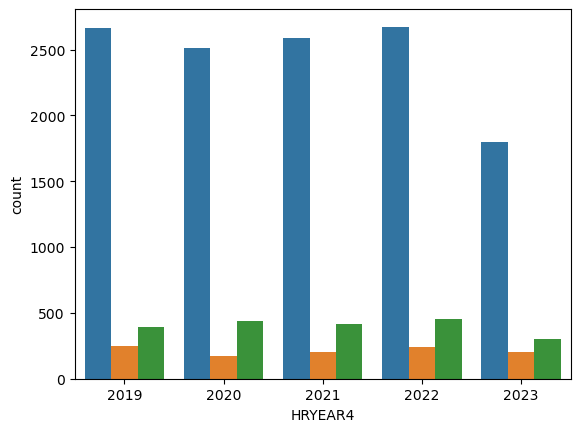

In [121]:
ax = sns.countplot(data=top16, x='HRYEAR4', hue='EMPSTAT')
ax.set_title('Employment Status by Year, Top 16% Variables')
ax.set_xlabel('Year')
ax.set_ylabel('Count')
plt.show()

In [160]:
aggregated_data = top16.groupby(['HRYEAR4','PEMLR']).count()
aggregated_data = aggregated_data[['TUCASEID']]
aggregated_data

TUCASEID
HRYEAR4 PEMLR          
2019    -1          238
         1          950
         2           65
         3           15
         4           52
         6         1630
         7          355
2020    -1          198
         1          876
         2           59
         3           53
         4           80
         6         1488
         7          372
2021    -1          240
         1          915
         2           77
         3            7
         4           99
         6         1509
         7          364
2022    -1          237
         1         1053
         2           72
         3           10
         4           76
         6         1528
         7          386
2023    -1          117
         1          787
         2           62
         3           12
         4           51
         6         1009
         7          260

In [190]:
agg_data = top16.groupby(['HRYEAR4','TELENOW']).count()
agg_data = agg_data[['TUCASEID']]
agg_data

TUCASEID
HRYEAR4 TELENOW          
2019    -1           3305
2020    -1           3126
2021    -1           3211
2022    -1           3098
         1             29
         2            235
2023    -1           1513
         1             76
         2            709